# 1.Libraries 
!! some libraries are depercated in last version of NoteBook

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import random
import cv2
import numpy as np
from tensorflow.keras.models import load_model
from keras.models import Model,Sequential
from tensorflow.keras import layers, models
from keras.layers import Conv2D, Flatten,Reshape,Dense,Input,Conv2DTranspose,LeakyReLU,Concatenate,Activation,Dropout,Multiply,Cropping2D,Add
import tensorflow as tf
from tensorflow.keras.optimizers import RMSprop,Adam
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.layers import BatchNormalization
from keras.applications.vgg19 import VGG19
from tensorflow.keras.callbacks import Callback, ModelCheckpoint
from tensorflow.keras.utils import to_categorical,plot_model
import warnings
tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)
warnings.filterwarnings('ignore')
tf.keras.backend.clear_session()

# 2.Normalize && Denormalize

In [2]:
def normalize(img):
    img = tf.cast(img, dtype=tf.float32) / 127.5 - 1.0  # Normalize images to [-1,1]
    return img

def denormalize(img):
        return (img + 1) / 2

# 3.Dataset Load

In [3]:
train_path = "/kaggle/input/50k-celebrity-faces-image-dataset/Celebrity_Faces_Dataset" # path of dataset
BATCH_SIZE = 128 # batch size
IMG_SIZE = (64, 64)  # (height, width)


# Load training 
"""
params for keras.utils.image_dataset_from_directory:
1) path
2) String describing the encoding of labels
3) img dims
4) batch size
5) shuffle 
"""

train_dataset = image_dataset_from_directory(
    train_path,
    label_mode=None,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
).map(normalize, num_parallel_calls=tf.data.AUTOTUNE)# normalize data set in graph mode call_AUTOTUNE_to prevent bottlenecks in memory

#cache Data to ram to reduce the overhead of fetching data from cpu
train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE).cache()

Found 50000 files.


Left images shape: (128, 64, 64, 3)


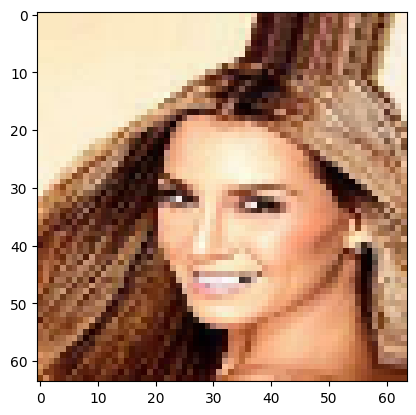

In [4]:
for left in train_dataset.take(1):
    print("Left images shape:", left.shape)   
    plt.imshow(denormalize(left[0]))


# 4.Upsample && Downsample block

In [5]:
#DownSampleBlock
def encoder_layer(inputs, filters, kernel_size=16, strides=2, activation=None, batch_norm=True):
    #conv layer
    conv = tf.keras.layers.SpectralNormalization(Conv2D(filters=filters,
                  kernel_size=kernel_size,
                  strides=strides,
                  padding='same'))
    x = conv(inputs)
    #batchnorm
    if batch_norm:
        x = BatchNormalization()(x)
    # Relu Activation
    if activation == 'relu':
        x = Activation('relu')(x)
    #LeakyRelu Activation to solve dead gradient issue
    if activation == 'leakyrelu':
        x = LeakyReLU(alpha=0.2)(x)
        

    return x
#UpSampleBlock_for_Generator
def decoder_layer_gen(inputs, filters, kernel_size=16, strides=2, activation='relu', batch_norm=False, apply_dropout=False, dropout_rate=0.5):
        # Transposed convolution layer.
        conv = Conv2DTranspose(filters=filters,
                               kernel_size=kernel_size,
                               strides=strides,
                               padding='same')
        
        x = conv(inputs)
        
        if batch_norm:
            x = BatchNormalization()(x)
        
        # Apply the specified activation.
        if activation == 'relu':
            x = Activation('relu')(x)
        elif activation == 'leakyrelu':
            x = LeakyReLU(alpha=0.2)(x)
        
        # Apply dropout if requested.
        if apply_dropout:
            x = Dropout(rate=dropout_rate)(x)
        return x

def decoder_layer_disc(inputs, paired_inputs, filters, kernel_size=16, strides=2, activation='relu', batch_norm=False, apply_dropout=False, dropout_rate=0.5):
        # Transposed convolution layer.
        conv = Conv2DTranspose(filters=filters,
                               kernel_size=kernel_size,
                               strides=strides,
                               padding='same')
        
        x = conv(inputs)
        #BatchNorm
        if batch_norm:
            x = BatchNormalization()(x)
        
        # Apply the specified activation.
        if activation == 'relu':
            x = Activation('relu')(x)
        elif activation == 'leakyrelu':
            x = LeakyReLU(alpha=0.2)(x)
        
        # Apply dropout if requested.
        if apply_dropout:
            x = Dropout(rate=dropout_rate)(x)
        #U-Net_SkipConnections        
        # Concatenate with the paired inputs.
        x = Concatenate()([x, paired_inputs])
        
        return x

# 5.Decoder_Block

In [6]:
def build_decoder(z_dim, name=None):
    """
    Decoder that matches the PyTorch version but uses decoder_layer_gen
    """
    inputs = Input(shape=(z_dim,))
    
    # Initial dense layer without activation (as in PyTorch)
    x = Dense(8 * 8 * 256, use_bias=False)(inputs)
    x = BatchNormalization(momentum=0.9)(x)
    x = tf.keras.layers.ReLU()(x)
    
    # Reshape to start convolutions (8x8x256)
    x = Reshape((8, 8, 256))(x)
    
    # Decoder layers matching PyTorch progression
    # First: size -> size (256 -> 256)
    d1 = decoder_layer_gen(x, 256, kernel_size=5, batch_norm=True)
    
    # Second: size -> size//2 (256 -> 128)
    d2 = decoder_layer_gen(d1, 128, kernel_size=5, batch_norm=True)
    
    # Third: size//2 -> size//4 (128 -> 64)
    d3 = decoder_layer_gen(d2, 64, kernel_size=5, batch_norm=True)
    
    # Final conv with Tanh (as in PyTorch)
    outputs = Conv2DTranspose(3, kernel_size=5, strides=1, padding='same', 
                             activation='tanh')(d3)
    
    # Create model
    generator = Model(inputs, outputs, name=name)
    return generator

# 6. U-Net Discrminator

In [7]:
def build_discriminator(input_shape, kernel_size, name=None):
    #Input_Layer
    inputs = Input(shape=input_shape)
    #DownSampleBlock1
    e1 = encoder_layer(inputs, 32, kernel_size=5,strides=1, activation='relu', batch_norm=False)
    #DownSampleBlock2,BatchNorm1
    e2 = encoder_layer(e1, 128, kernel_size=5, activation='relu', batch_norm=True)
    #DownSampleBlock3,BatchNorm2
    e3 = encoder_layer(e2, 256, kernel_size=5, activation='relu', batch_norm=True)
    #DownSampleBlock4,BatchNorm3
    e4 = encoder_layer(e3, 256, kernel_size=5, activation='relu', batch_norm=True)
    #DownSampleBlock5,BatchNorm4
    #GlobalAvg less params compared to Flatten-->Dense
    global_features = layers.GlobalAveragePooling2D()(e4)
    #Score Real/Fake
    global_output = layers.Dense(1, activation='sigmoid', name='global_output')(global_features)
    #UpSampleBlock1 with U-Net SkipConnections,Dropout,BatchNorm
    d1 = decoder_layer_disc(e4,e3,256,kernel_size=5,apply_dropout=False,batch_norm=True)
    #UpSampleBlock2 with U-Net SkipConnections,Dropout,BatchNorm
    d2 = decoder_layer_disc(d1,e2,128,kernel_size=5,apply_dropout=False,batch_norm=True)
    #UpSampleBlock3 with U-Net SkipConnections,BatchNorm
    d3 = decoder_layer_disc(d2,e1,64,kernel_size=5,batch_norm=True)
    #UpSampleBlock4 with U-Net SkipConnections,BatchNorm
    #PatchGAN--->UpSampleBlock5 from (32)channels into 3(channels) with_Sigmoid_Activation
    d4 = Conv2D(3, kernel_size=1, strides=1,activation='sigmoid',padding='same')(d3)
    #return pixel_wise_loss && global loss (score)
    discriminator = Model(inputs, [d4,global_output], name=name)
    return discriminator



# 7.VGG19

In [8]:
def build_perceptual_model():
    # Load VGG19 without top layers
    base_model = VGG19(weights='imagenet', include_top=False, input_shape=(64, 64, 3))
    
    # Freeze the model
    for layer in base_model.layers:
        layer.trainable = False
    
    # Use intermediate layers instead of your fully connected ones
    # Common choices are 'block2_conv2', 'block3_conv3', 'block4_conv3'
    layer_outputs = [base_model.get_layer('block2_conv2').output]
    
    # Create model that outputs features from selected layers
    perceptual_model = Model(inputs=base_model.input, outputs=layer_outputs)
    
    return perceptual_model

In [9]:
decoder = build_decoder(128)
perceptual_model = build_perceptual_model()
discriminator = build_discriminator((64,64,3),5)
decoder.summary()
discriminator.summary()

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 16384)               │       2,097,152 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 16384)               │          65,536 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu (ReLU)                         │ (None, 16384)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape (Reshape)                    │ (None, 8, 8, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_transpose (Conv2DTranspose)   │ (None, 16, 16, 256)         │       1,638,656 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 16, 16, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 16, 16, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_transpose_1 (Conv2DTranspose) │ (None, 32, 32, 128)         │         819,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 32, 32, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 32, 32, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_transpose_2 (Conv2DTranspose) │ (None, 64, 64, 64)          │         204,864 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 64, 64, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 64, 64, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_transpose_3 (Conv2DTranspose) │ (None, 64, 64, 3)           │           4,803 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,832,131 (18.43 MB)

 Trainable params: 4,798,467 (18.30 MB)

...

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2             │ (None, 64, 64, 3)      │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ spectral_normalization    │ (None, 64, 64, 32)     │          2,464 │ input_layer_2[0][0]    │
│ (SpectralNormalization)   │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_3 (Activation) │ (None, 64, 64, 32)     │              0 │ spectral_normalizatio… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ spectral_normalization_1  │ (None, 32, 32, 128)    │        102,656 │ activation_3[0][0]     │
│ (SpectralNormalization)   │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_4     │ (None, 32, 32, 128)    │            512 │ spectral_normalizatio… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_4 (Activation) │ (None, 32, 32, 128)    │              0 │ batch_normalization_4… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ spectral_normalization_2  │ (None, 16, 16, 256)    │        819,712 │ activation_4[0][0]     │
│ (SpectralNormalization)   │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_5     │ (None, 16, 16, 256)    │          1,024 │ spectral_normalizatio… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_5 (Activation) │ (None, 16, 16, 256)    │              0 │ batch_normalization_5… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ spectral_normalization_3  │ (None, 8, 8, 256)      │      1,638,912 │ activation_5[0][0]     │
│ (SpectralNormalization)   │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_6     │ (None, 8, 8, 256)      │          1,024 │ spectral_normalizatio… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_6 (Activation) │ (None, 8, 8, 256)      │              0 │ batch_normalization_6… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_transpose_4        │ (None, 16, 16, 256)    │      1,638,656 │ activation_6[0][0]     │
│ (Conv2DTranspose)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_7     │ (None, 16, 16, 256)    │          1,024 │ conv2d_transpose_4[0]… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_7 (Activat

 Total params: 6,255,492 (23.86 MB)

 Trainable params: 6,252,644 (23.85 MB)

 Non-trainable params: 2,848 (11.12 KB)

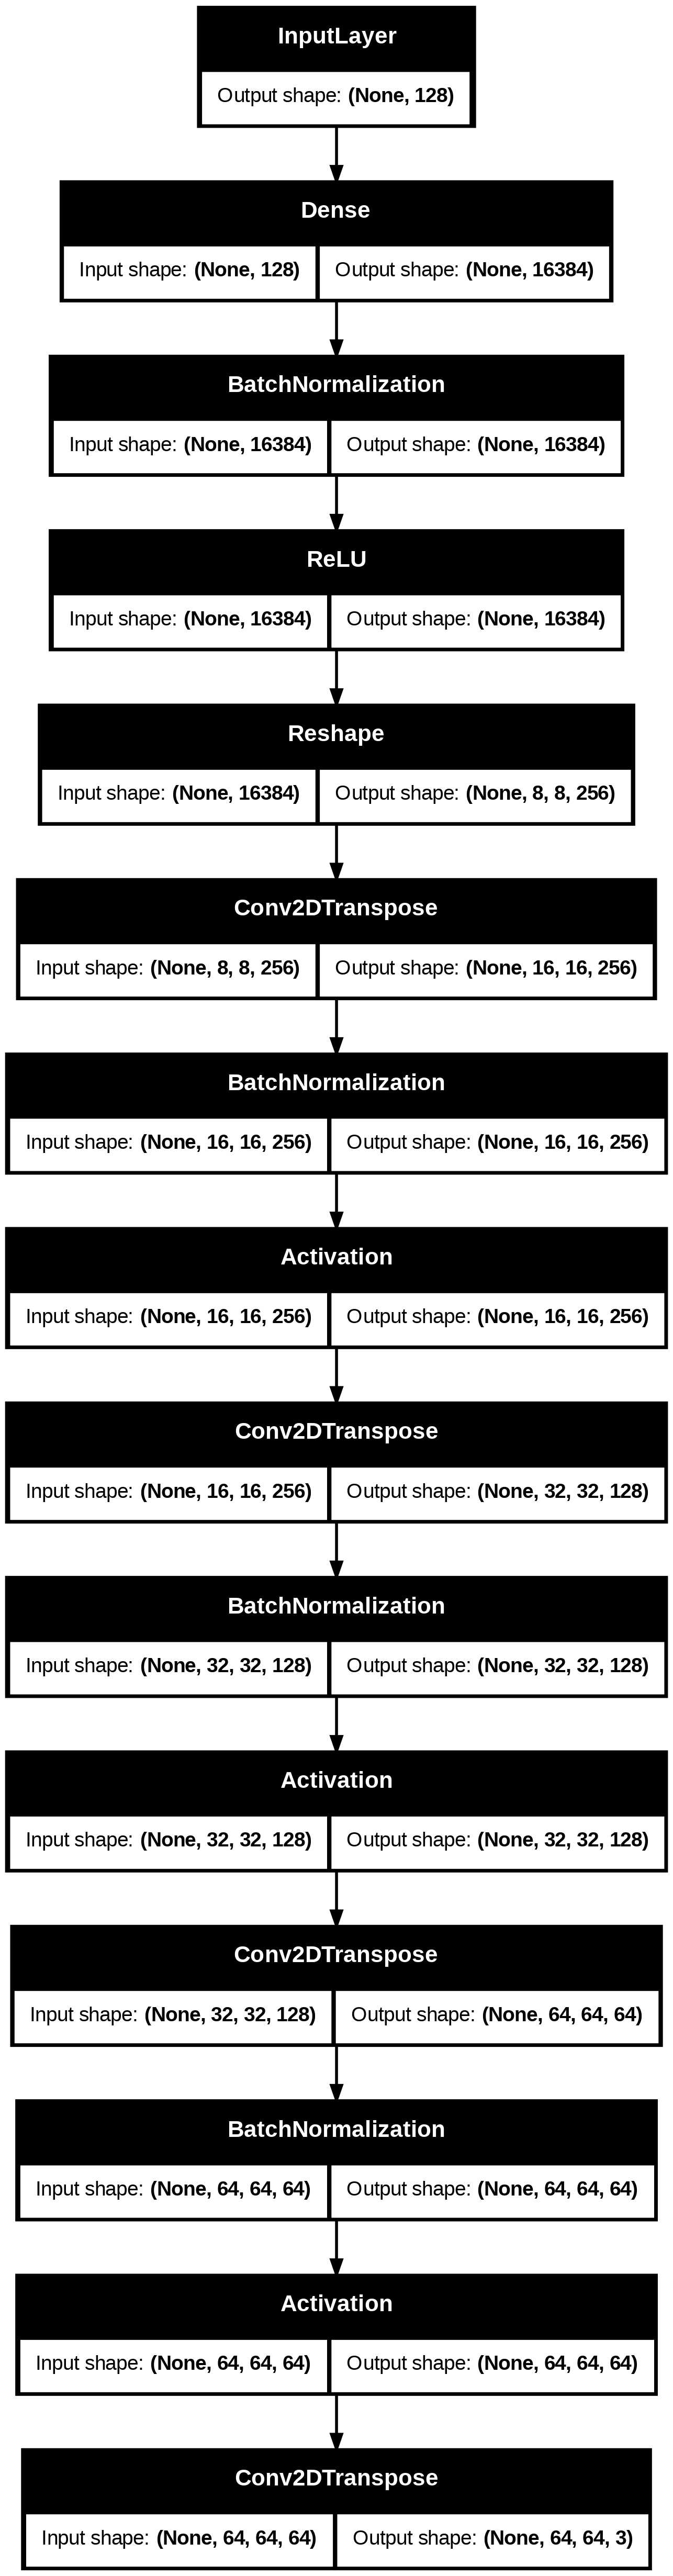

In [10]:
plot_model(decoder,
           show_shapes=True,
           to_file='Decoder.png',
          )

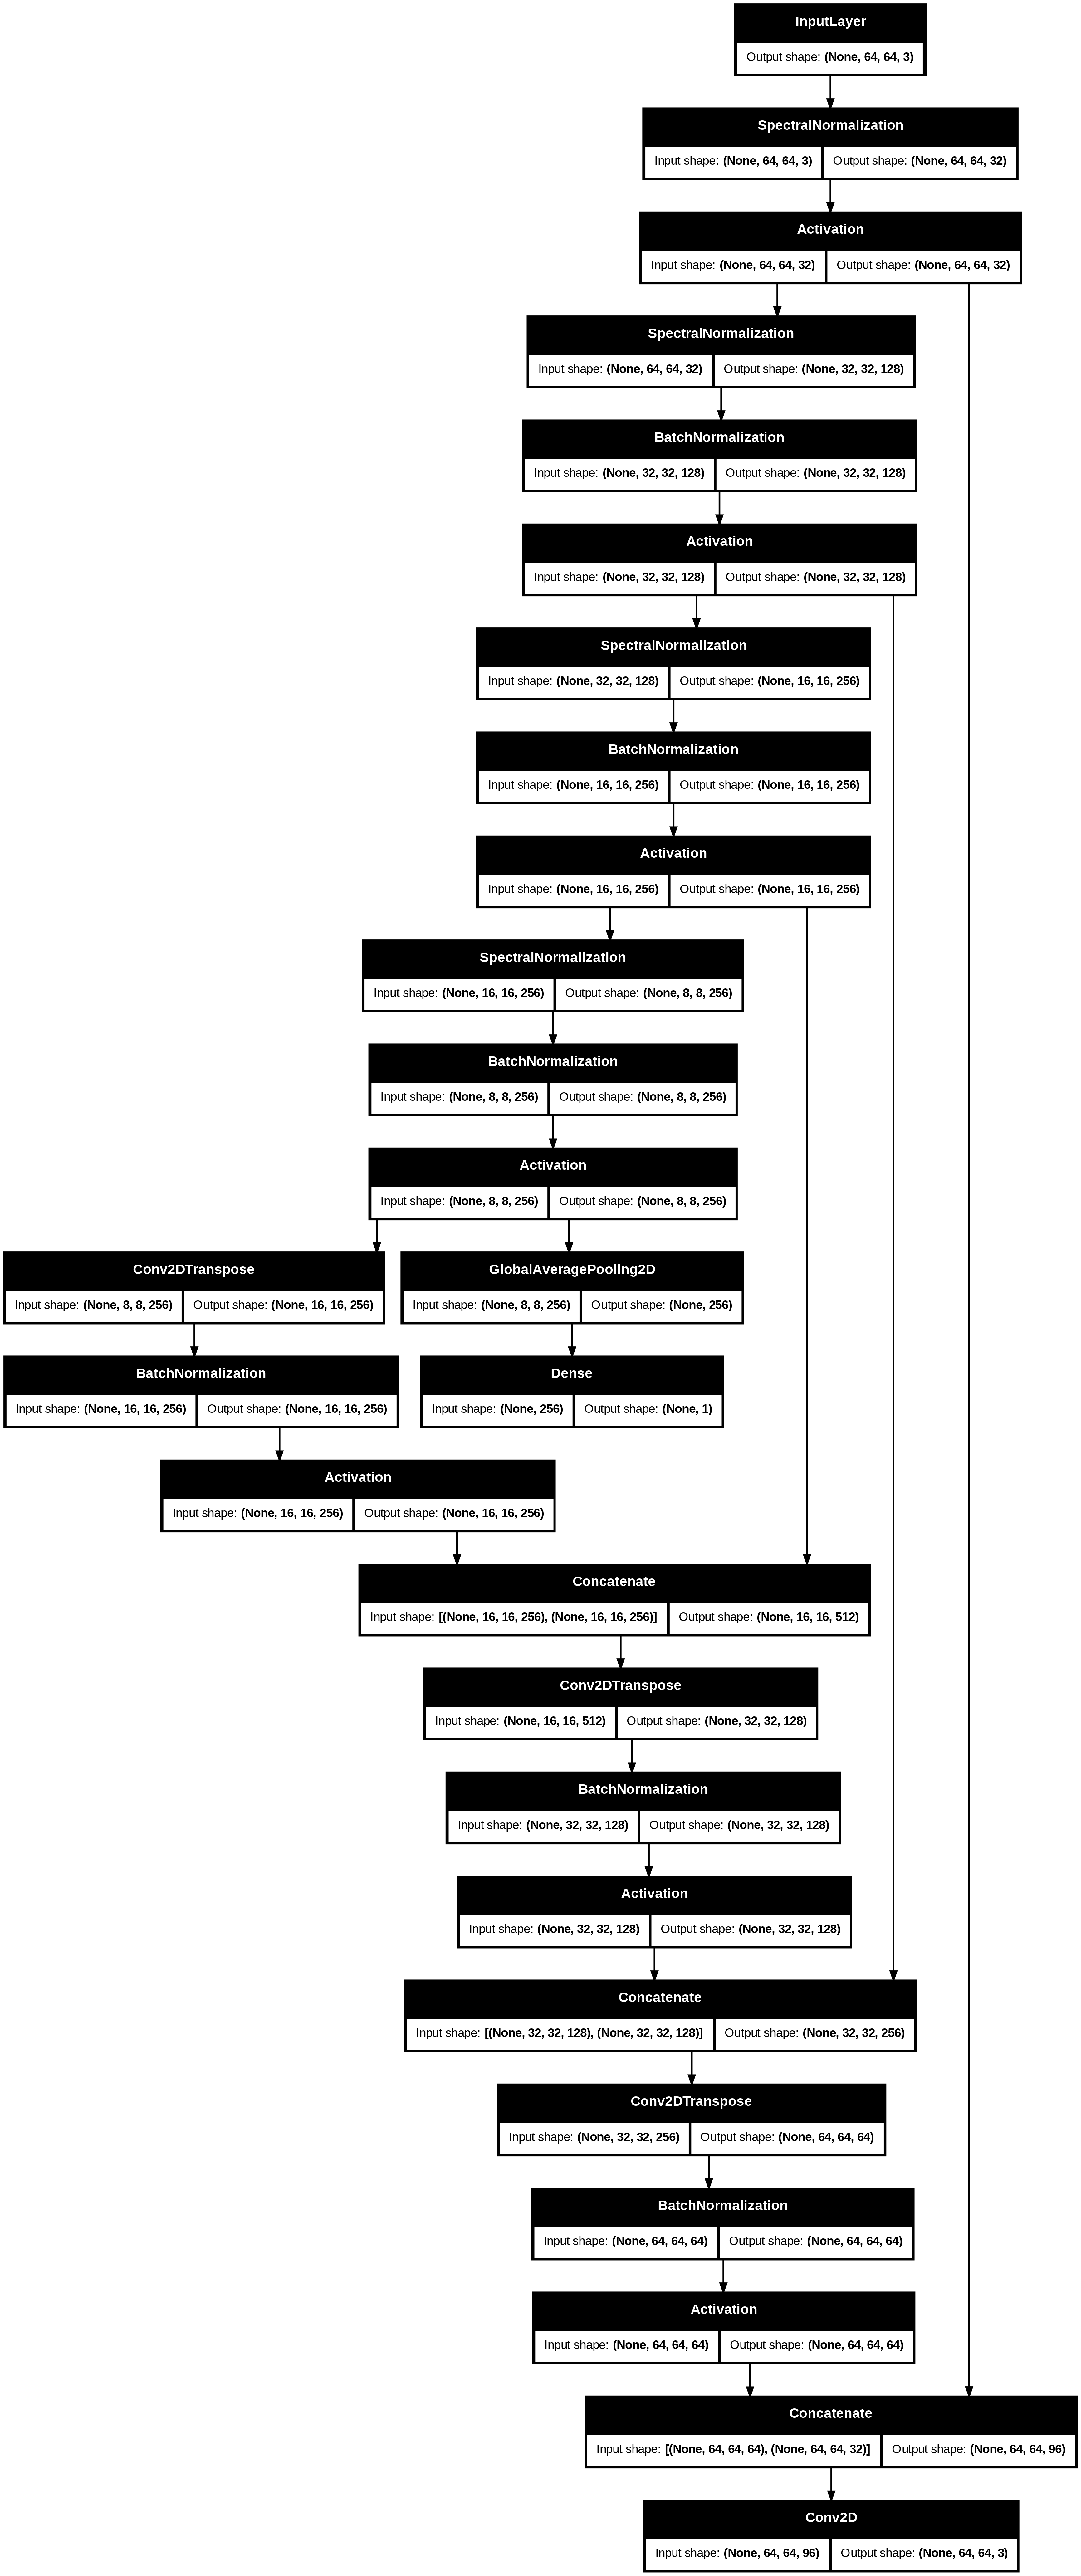

In [11]:
plot_model(discriminator,
           show_shapes=True,
           to_file='Discriminator.png',
          )

# 8. Sampling Layer for Vae Part

In [12]:
class Sampling(tf.keras.layers.Layer):
    """Uses (z_mean, z_log_var) to sample z, the vector encoding a digit."""
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        """Add epsilon for reparamtrization trick so we can backpropgate through custom layer"""
        epsilon = tf.keras.backend.random_normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

# 9.Encoder vae

In [13]:
latent_dim = 128

# Input Layer
encoder_inputs = tf.keras.Input(shape=(64, 64, 3))

# EncoderBlock 1: 3 -> 64 channels
x = layers.Conv2D(64, kernel_size=5, padding="same", strides=2, use_bias=False)(encoder_inputs)
x = tf.keras.layers.BatchNormalization(momentum=0.9)(x)
x = layers.ReLU()(x)

# EncoderBlock 2: 64 -> 128 channels
x = layers.Conv2D(128, kernel_size=5, padding="same", strides=2, use_bias=False)(x)
x = tf.keras.layers.BatchNormalization(momentum=0.9)(x)
x = layers.ReLU()(x)

# EncoderBlock 3: 128 -> 256 channels
x = layers.Conv2D(256, kernel_size=5, padding="same", strides=2, use_bias=False)(x)
x = tf.keras.layers.BatchNormalization(momentum=0.9)(x)
x = layers.ReLU()(x)

# Flatten Layer (8×8×256)
x = layers.Flatten()(x)

# Dense layer with 1024 units
x = layers.Dense(1024, use_bias=False)(x)
x = tf.keras.layers.BatchNormalization(momentum=0.9)(x)
x = layers.ReLU()(x)

# Mean and Variance
z_mean = layers.Dense(latent_dim)(x)
z_log_var = layers.Dense(latent_dim)(x)

# Sampling using custom layer
z = Sampling()([z_mean, z_log_var])

# Encoder model
encoder = tf.keras.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")

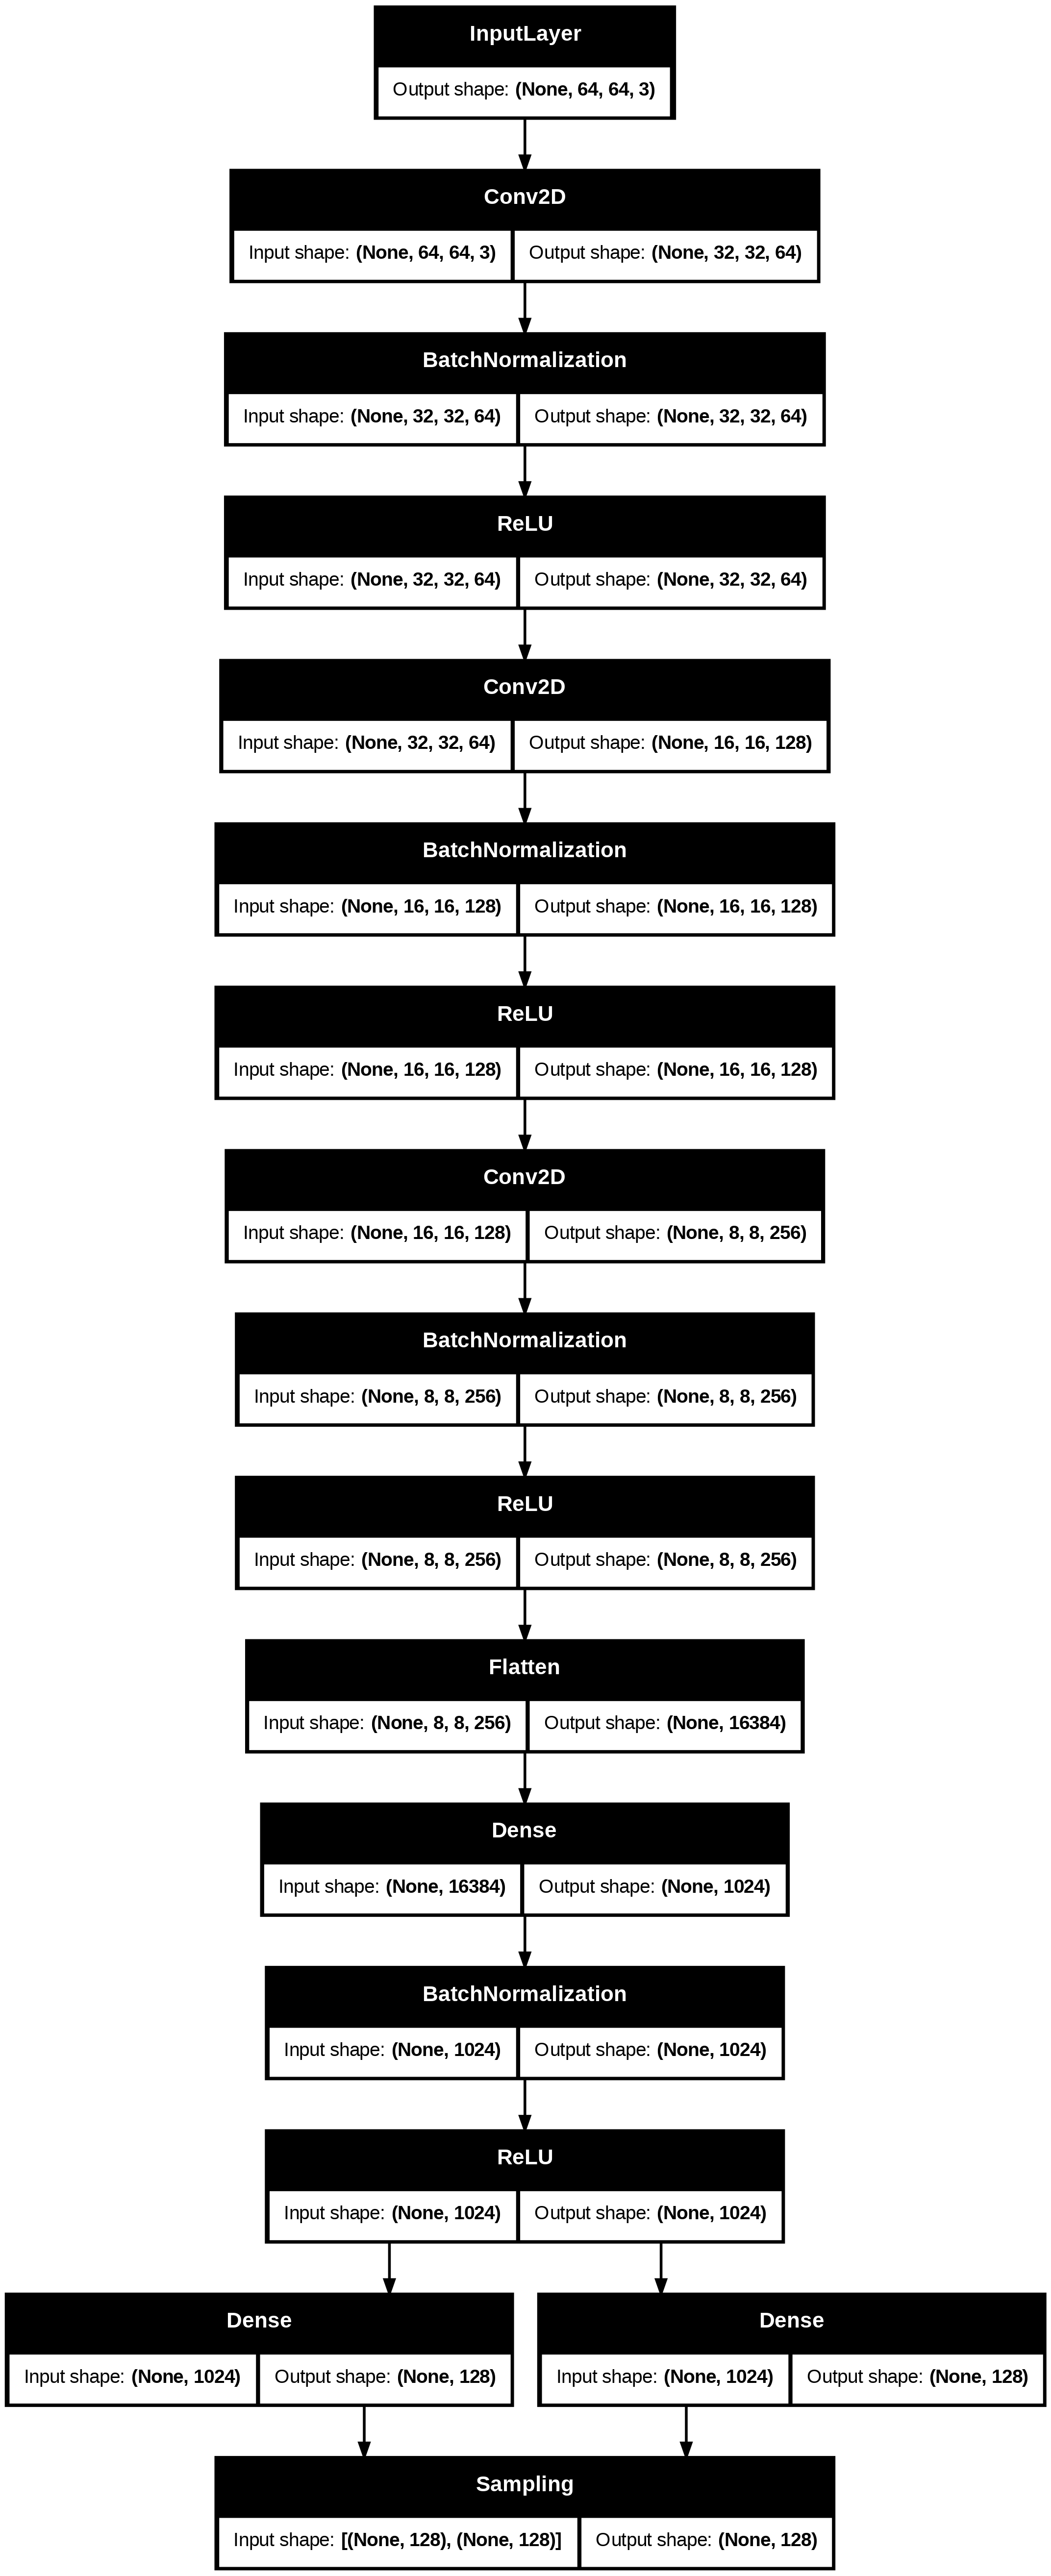

In [14]:
plot_model(encoder,
           show_shapes=True,
            to_file='Encoder.png',
          )

# **GAN Main Class** (loss_calculation,compile_opts)

In [15]:
class GAN(tf.keras.Model):
    def __init__(self, encoder, decoder, discriminator, z_dim,perceptual_model):
        super(GAN, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.discriminator = discriminator
        self.z_dim = z_dim
        self.perceptual_model = perceptual_model
    def compile(self, g1_optimizer, g2_optimizer, d_optimizer, loss_fn):
        super(GAN, self).compile()
        self.g1_optimizer = g1_optimizer
        self.g2_optimizer = g2_optimizer
        self.d_optimizer = d_optimizer
        self.loss_fn = loss_fn
        
    @tf.function
    def train_step(self, real_images):
        batch_size = tf.shape(real_images)[0]
        
        # Sample noise from prior
        noise = tf.random.normal(shape=(batch_size, self.z_dim))
        
        # Train the discriminator and generators
        with tf.GradientTape() as d_tape, tf.GradientTape() as enc_tape, tf.GradientTape() as dec_tape:
            # Encode real images to latent space
            mean, log_var, z = self.encoder(real_images, training=True)
            
            # Generate images from both encoded latent space and prior noise
            generated_images = self.decoder(z, training=True)
            prior_generated_images = self.decoder(noise, training=True)
            
            # Get discriminator outputs for real and all generated images
            disc_real_image_pixel, disc_real_image_global = self.discriminator(real_images, training=True)
            disc_fake_image_pixel, disc_fake_image_global = self.discriminator(generated_images, training=True)
            disc_prior_image_pixel, disc_prior_image_global = self.discriminator(prior_generated_images, training=True)
            
            # Discriminator losses
            # Real images
            d_loss_real = (tf.reduce_mean(self.loss_fn(tf.ones_like(disc_real_image_pixel), disc_real_image_pixel)) + 
                          self.loss_fn(tf.ones_like(disc_real_image_global), disc_real_image_global))
            
            # Fake images from encoder
            d_loss_fake = (tf.reduce_mean(self.loss_fn(tf.zeros_like(disc_fake_image_pixel), disc_fake_image_pixel)) + 
                          self.loss_fn(tf.zeros_like(disc_fake_image_global), disc_fake_image_global))
            
            # Fake images from prior
            d_loss_prior = (tf.reduce_mean(self.loss_fn(tf.zeros_like(disc_prior_image_pixel), disc_prior_image_pixel)) + 
                           self.loss_fn(tf.zeros_like(disc_prior_image_global), disc_prior_image_global))
            
            # Total discriminator loss
            d_loss = d_loss_real + d_loss_fake + d_loss_prior
            
            # Generator losses
            # For encoded images
            g_loss_fake = (tf.reduce_mean(self.loss_fn(tf.ones_like(disc_fake_image_pixel), disc_fake_image_pixel)) + 
                          self.loss_fn(tf.ones_like(disc_fake_image_global), disc_fake_image_global))
            
            # For prior generated images
            g_loss_prior = (tf.reduce_mean(self.loss_fn(tf.ones_like(disc_prior_image_pixel), disc_prior_image_pixel)) + 
                           self.loss_fn(tf.ones_like(disc_prior_image_global), disc_prior_image_global))
            
            # VAE KL divergence loss
            kl_loss = -0.5 * tf.reduce_mean(1 + log_var - tf.square(mean) - tf.exp(log_var))
            
            # Reconstruction loss
            reconstruction_loss = tf.reduce_mean(tf.abs(real_images - generated_images))

            #perceptual loss
            fake_features = self.perceptual_model(generated_images)
            real_features = self.perceptual_model(real_images)
            perceptual_loss = tf.reduce_mean(tf.square(fake_features - real_features))

            
            # Total losses for encoder and decoder
            enc_loss = kl_loss + reconstruction_loss + 0.8* perceptual_loss
            dec_loss = (g_loss_fake + g_loss_prior) + 10 * reconstruction_loss + 0.8 * perceptual_loss
            
            
            
        # Compute and apply gradients
        d_gradients = d_tape.gradient(d_loss, self.discriminator.trainable_variables)
        self.d_optimizer.apply_gradients(zip(d_gradients, self.discriminator.trainable_variables))
        
        g1_gradients = enc_tape.gradient(enc_loss, self.encoder.trainable_variables)
        self.g1_optimizer.apply_gradients(zip(g1_gradients, self.encoder.trainable_variables))
        
        g2_gradients = dec_tape.gradient(dec_loss, self.decoder.trainable_variables)
        self.g2_optimizer.apply_gradients(zip(g2_gradients, self.decoder.trainable_variables))
        
        return {
            "d_loss": d_loss,
            "enc_loss": enc_loss,
            "dec_loss": dec_loss,
        }
    
    @tf.function
    def generate(self, n_samples):
        """Generate samples from the prior noise distribution"""
        noise = tf.random.normal(shape=(n_samples, self.z_dim))
        return self.decoder(noise, training=False)
    
    @tf.function
    def reconstruct(self, images):
        """Reconstruct images through the VAE"""
        mean, log_var, z = self.encoder(images, training=False)
        return self.decoder(z, training=False)

In [16]:
class VisualizationCallback(Callback):
    def __init__(self, encoder, decoder, denormalize, validation_data=None):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.denormalize = denormalize
        self.validation_data = validation_data  # Validation dataset to get real images
        self.latent_dim = decoder.input_shape[-1]
        
    def on_epoch_end(self, epoch, logs=None):
        if epoch % 4 == 0:  # Visualize every 10 epochs
            fig, axes = plt.subplots(1, 3, figsize=(15, 5))
            
            # Get a real image from validation data
            if isinstance(self.validation_data, tf.data.Dataset):
                for batch in self.validation_data.take(1):
                    if isinstance(batch, tuple):
                        real_images = batch[0]  # If dataset returns (images, labels)
                    else:
                        real_images = batch
                    break
            else:
                real_images = self.validation_data[0:1]  # Take first image
            
            # 1. Show original image
            original_img = self.denormalize(real_images[0])
            axes[0].imshow(original_img)
            axes[0].set_title(f"Original (Epoch {epoch})")
            axes[0].axis("off")
            
            # 2. Show reconstructed image
            mean, log_var, z = self.encoder(real_images, training=False)
            reconstructed = self.decoder(z, training=False)
            reconstructed_img = self.denormalize(reconstructed[0])
            axes[1].imshow(reconstructed_img)
            axes[1].set_title(f"Reconstructed (Epoch {epoch})")
            axes[1].axis("off")
            
            # 3. Show generated image from random noise
            random_latent_vector = tf.random.normal(shape=(1, self.latent_dim))
            generated = self.decoder(random_latent_vector, training=False)
            generated_img = self.denormalize(generated[0])
            axes[2].imshow(generated_img)
            axes[2].set_title(f"Generated from Noise (Epoch {epoch})")
            axes[2].axis("off")
            
            plt.tight_layout()
            # Save the figure
            plt.savefig(f'vae_gan_results_epoch_{epoch}.png')
            plt.close()

# Example usage:
def denormalize_image(img):
    """Convert normalized tensor image to displayable format"""
    img = tf.cast(img, tf.float32)
    img = (img + 1) * 127.5  # Convert from [-1, 1] to [0, 255]
    img = tf.clip_by_value(img, 0, 255)
    img = tf.cast(img, tf.uint8)
    return img.numpy()

# When creating the callback:
visualization_callback = VisualizationCallback(
    encoder=encoder,
    decoder=decoder,
    denormalize=denormalize_image,
    validation_data=train_dataset  # Your validation dataset
)

# 10.Compile and init components

In [17]:
gan = GAN(encoder,decoder,discriminator,128,perceptual_model)
# Define optimizers and loss function
g1_optimizer = tf.keras.optimizers.Adam(learning_rate=5e-4, beta_1=0.5,beta_2=0.999)
g2_optimizer = tf.keras.optimizers.Adam(learning_rate=5e-4, beta_1=0.5,beta_2=0.999)
d_optimizer = tf.keras.optimizers.Adam(learning_rate=1e-5, beta_1=0.5,beta_2=0.999)
loss_fn = tf.keras.losses.BinaryCrossentropy()
gan.compile(g1_optimizer,g2_optimizer, d_optimizer, loss_fn)

# 11.Train Step 

In [ ]:
hist = gan.fit(train_dataset,epochs=25,callbacks=[visualization_callback])

Epoch 1/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 841s 2s/step - d_loss: 3.8578 - dec_loss: 20.9177 - enc_loss: 1119705890816.0000
Epoch 2/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 703s 2s/step - d_loss: 3.6828 - dec_loss: 18.2642 - enc_loss: 12.7862
Epoch 3/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 704s 2s/step - d_loss: 3.6867 - dec_loss: 17.9224 - enc_loss: 12.3067
Epoch 4/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 705s 2s/step - d_loss: 3.6948 - dec_loss: 17.5426 - enc_loss: 12.0166
Epoch 5/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 706s 2s/step - d_loss: 3.5974 - dec_loss: 17.1843 - enc_loss: 11.6880
Epoch 6/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 705s 2s/step - d_loss: 3.7242 - dec_loss: 17.0714 - enc_loss: 11.7431
Epoch 7/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 705s 2s/step - d_loss: 3.6490 - dec_loss: 16.7868 - enc_loss: 11.4803
Epoch 8/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 704s 2s/step - d_loss: 3.5454 - dec_loss: 16.6102 - enc_loss: 11.2084
Epoch 9/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 705s 2s/step - d_loss: 3.7426 - dec_loss: 16.4370 - enc_loss: 11.3411

# 12.**Save Whole components** (opt,architecure,etc)

In [19]:
encoder.save("encoder p-vae mix 0.8 with l1.h5")
decoder.save("decoder p-vae mix 0.8 with l1.h5")
discriminator.save("discriminator p-vae mix 0.8 with l1.h5")